# Lab 12: Turniej Modeli — ewaluacja i finał

W tym notebooku przeprowadzamy pełną ewaluację modeli z lab11:
krzywe ROC, cross-validation, porównanie modeli i raport końcowy.

## 1. Importy i konfiguracja

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_validate, StratifiedKFold,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
)

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_style("whitegrid")

RANDOM_STATE = 42

## 2. Wczytanie danych i trenowanie modeli

Powtarzamy przygotowanie danych i trenowanie z lab11.

In [2]:
# Wczytaj dataset
df = pd.read_csv("dataset.csv")

# Jeśli nie masz dataset.csv, odkomentuj poniższy blok:
# from sklearn.datasets import make_classification
# X_synth, y_synth = make_classification(
#     n_samples=200, n_features=8, n_informative=5,
#     n_redundant=2, weights=[0.7, 0.3], random_state=42,
# )
# feature_cols = ["loc", "avg_cc", "max_cc", "num_functions",
#                 "churn", "num_commits", "num_authors", "age_days"]
# df = pd.DataFrame(X_synth, columns=feature_cols)
# df["is_buggy"] = y_synth

feature_cols = ["loc", "avg_cc", "max_cc", "num_functions",
                "churn", "num_commits", "num_authors", "age_days"]
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols].fillna(df[feature_cols].median())
y = df["is_buggy"]

print(f"Dataset: {len(df)} wierszy, cechy: {feature_cols}")
print(f"Buggy: {y.sum()}, Clean: {(y == 0).sum()}")

Dataset: 1156 wierszy, cechy: ['loc', 'avg_cc', 'max_cc', 'num_functions', 'churn', 'num_commits', 'num_authors', 'age_days']
Buggy: 493, Clean: 663


In [3]:
# Podział train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Standaryzacja (dla regresji logistycznej)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 924, Test: 232


In [4]:
# Trenowanie 3 modeli
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

dt = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Modele wytrenowane.")

Modele wytrenowane.


## 3. Metryki ewaluacji (Zadanie 1)

In [5]:
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_proba_dt = dt.predict_proba(X_test)[:, 1]
y_proba_rf = rf.predict_proba(X_test)[:, 1]

metrics = pd.DataFrame({
    "Model": ["Regresja logistyczna", "Drzewo decyzyjne", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
    ],
    "F1": [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
    ],
    "AUC-ROC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test, y_proba_rf),
    ],
})

metrics.style.format({"Accuracy": "{:.3f}", "Precision": "{:.3f}",
                       "Recall": "{:.3f}", "F1": "{:.3f}", "AUC-ROC": "{:.3f}"})

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Regresja logistyczna,0.789,0.857,0.606,0.710,0.887
1,Drzewo decyzyjne,0.759,0.812,0.566,0.667,0.839
2,Random Forest,0.784,0.788,0.677,0.728,0.885


### 3.1 Krzywe ROC

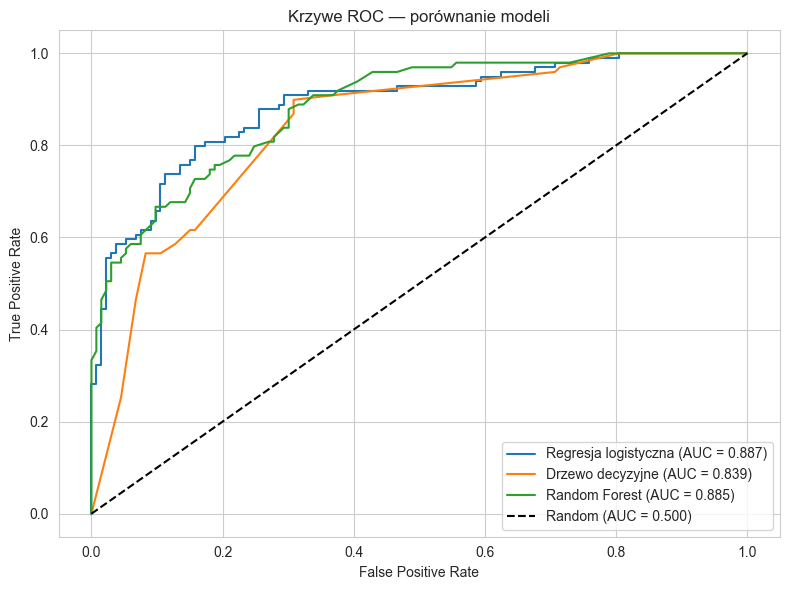

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_proba in [
    ("Regresja logistyczna", y_proba_lr),
    ("Drzewo decyzyjne", y_proba_dt),
    ("Random Forest", y_proba_rf),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Krzywe ROC — porównanie modeli")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Odpowiedzi (Zadanie 1)

**1. Który model ma najwyższe AUC-ROC? Czy to ten sam, który miał najwyższe accuracy?**

Najwyższe AUC-ROC ma regresja logistyczna (0.887), minimalnie wyprzedzając Random Forest (0.885). W lab11 tak samo, regresja logisyczna miała największe Accuracy (0.789), a potem random forest (0.784).

**2. Co oznacza AUC = 0.5? A AUC = 1.0?**

AUC = 0.5 oznacza model losowy - model nie potrafi odróżnić klasy buggy od clean.

AUC = 1.0 oznacza model doskonały

**3. Dlaczego AUC-ROC jest lepszą metryką niż accuracy dla niezbalansowanych datasetów?**

Accuracy przy stosunku klas 42,6% / 57,4% może być myląca, bo taki model zawsze przewidujący „clean" osiągnąłby ~57% accuracy bez żadnej użyteczności, a AUC-ROC mierzy zdolność modelu do rozróżniania klas, niezależnie od progu decyzyjnego, co jest kluczowe przy niezbalansowanych danych.

## 4. Cross-validation (Zadanie 2)

In [7]:
from sklearn.pipeline import make_pipeline

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

lr_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
)

cv_lr = cross_validate(lr_pipeline, X, y, cv=cv, scoring=scoring)
cv_dt = cross_validate(
    DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
    X, y, cv=cv, scoring=scoring
)
cv_rf = cross_validate(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    X, y, cv=cv, scoring=scoring
)

print("Cross-validation zakończona.")

Cross-validation zakończona.


In [8]:
def cv_summary(cv_results, name):
    return {
        "Model": name,
        "Accuracy": f"{cv_results['test_accuracy'].mean():.3f} +/- {cv_results['test_accuracy'].std():.3f}",
        "Precision": f"{cv_results['test_precision'].mean():.3f} +/- {cv_results['test_precision'].std():.3f}",
        "Recall": f"{cv_results['test_recall'].mean():.3f} +/- {cv_results['test_recall'].std():.3f}",
        "F1": f"{cv_results['test_f1'].mean():.3f} +/- {cv_results['test_f1'].std():.3f}",
        "AUC-ROC": f"{cv_results['test_roc_auc'].mean():.3f} +/- {cv_results['test_roc_auc'].std():.3f}",
    }

cv_table = pd.DataFrame([
    cv_summary(cv_lr, "Regresja logistyczna"),
    cv_summary(cv_dt, "Drzewo decyzyjne"),
    cv_summary(cv_rf, "Random Forest"),
])

cv_table

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Regresja logistyczna,0.802 +/- 0.023,0.842 +/- 0.034,0.661 +/- 0.062,0.739 +/- 0.037,0.886 +/- 0.018
1,Drzewo decyzyjne,0.788 +/- 0.036,0.799 +/- 0.069,0.682 +/- 0.081,0.731 +/- 0.052,0.854 +/- 0.028
2,Random Forest,0.817 +/- 0.033,0.813 +/- 0.043,0.742 +/- 0.065,0.774 +/- 0.044,0.891 +/- 0.020


C:\Users\Szymon\AppData\Local\Temp\ipykernel_58964\1426849865.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=["LR", "DT", "RF"])
C:\Users\Szymon\AppData\Local\Temp\ipykernel_58964\1426849865.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=["LR", "DT", "RF"])
C:\Users\Szymon\AppData\Local\Temp\ipykernel_58964\1426849865.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=["LR", "DT", "RF"])


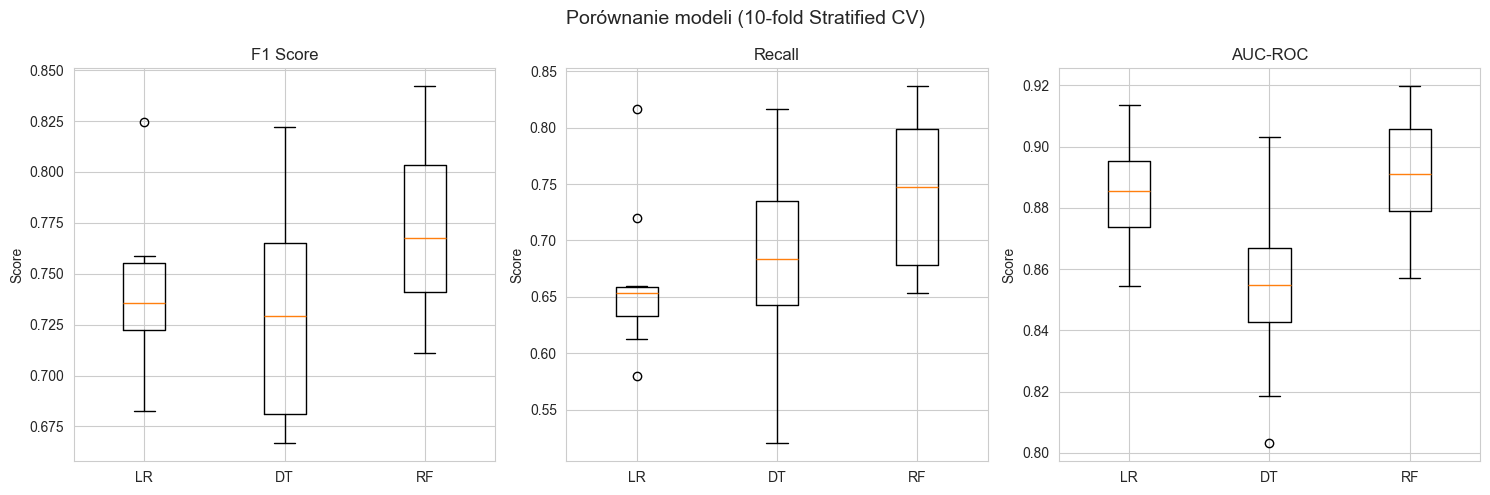

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (metric, title) in enumerate([
    ("test_f1", "F1 Score"),
    ("test_recall", "Recall"),
    ("test_roc_auc", "AUC-ROC"),
]):
    data = [cv_lr[metric], cv_dt[metric], cv_rf[metric]]
    axes[i].boxplot(data, labels=["LR", "DT", "RF"])
    axes[i].set_title(title)
    axes[i].set_ylabel("Score")

plt.suptitle("Porównanie modeli (10-fold Stratified CV)", fontsize=14)
plt.tight_layout()
plt.show()

### Odpowiedzi (Zadanie 2)

**1. Który model ma najwyższy średni F1? A najwyższy AUC-ROC?**

Random Forest wygrywa w obu metrykach. F1 (0.774 +/- 0.044) oraz najwyższe AUC-ROC (0.891 +/- 0.020

**2. Który model jest najbardziej stabilny (najniższe std)?**

Regresja logistyczna ma najmniejsze std we wszystkich metrykach.

**3. Czy ranking modeli zmienił się w porównaniu z lab11?**

W lab11 ranking to Regresja logistyczna, Random Forest, Decision Tree, a tutaj dwa pierwsze miejsca zamieniły się miejscami, a drzewo decyzyjne nadal jest na końcu.

**4. Czy różnice między modelami mają praktyczne znaczenie?**

Pierwsze dwa modele mają bardzo zbliżone AUC-ROC, ale Random Forest ma wyraźnie lepsze F1, co może być ważne w praktyce, jeśli zależy nam na równowadze między precyzją a recallem. Drzewo decyzyjne jest znacznie gorsze od dwóch pozostałych, więc różnica między nim a pozostałymi jest praktycznie istotna.

## 5. Raport końcowy (Zadanie 3)

Podsumowanie podróży od lab01 do lab12.

### 5.1 Projekt

**Jaki projekt OSS analizowaliście? Dlaczego go wybraliście?**

yt-dlp -> pobieranie video z YT, blisko mojemu sercu (mp3 FTW)
Poza tym, jest duży

### 5.2 Dataset

**Jak budowaliście dataset? Ile plików, ile cech? Jak etykietowaliście? Czy dataset był zbalansowany?**

Dataset był budowany na podstawie notebooka z lab10, czyli Path.rglob("*.py"), + metryki obliczane przez radon i git log --numstat

### 5.3 Feature importance

**Które metryki kodu najlepiej predykują defekty? Czy to zgadza się z intuicją?**

Według Feature importance:
 - num_commits: 0.258
 - churn: 0.174
 - num_authors: 0.124
 - loc: 0.122
 - age_days: 0.122
 - avg_cc: 0.072

Zgodne z intuicją, bo im więcej zmian i autorów, tym większe ryzyko błędu

### 5.4 Najlepszy model

**Który model wybralibyście do produkcji? Dlaczego? Jaką metrykę optymalizowalibyście?**

Random Forest, najlepsze wyniki w F1 i AUC-ROC, a przy tym nadal dość stabilny. Metryką do optymalizacji byłby recall dla klasy buggy, nie accuracy, bo chcemy złapać jak najwięcej defektów, nawet kosztem większej liczby false positives, które możemy później ręcznie zweryfikować.

### 5.5 Ograniczenia

**Jakie są ograniczenia waszego podejścia? Co zrobilibyście inaczej?**

Na 100% jakość etykiet, problem z `fix`, bo `fix typo` nie jest bugiem itp. no i oczywiście trening nie tylko na jedym repo :) 

### 5.6 Wnioski z kursu

**Co zapamiętaliście z 12 labów? Które narzędzie okazało się najbardziej użyteczne?**

Że takie rzeczy jak bugi czy złożoność kodu da się jakkolwiek skwantyfikować i policzyć, mind blown tbh. Na pewno będę korzystać z sonarclouda, bo jak jest darmowy i działa...

Super laby btw